# Задание 11. Варианты разбиения выборки и оценка модели

Что нужно сделать:
- взять модель классификации цифр MNIST из задания 10 (часть 2) — там для оценки использовалось одно
  простое разбиение train-test;
- оценить ту же модель четырьмя разными способами разбиения выборки:
  - train-test split со стратификацией,
  - K-fold со стратификацией, k = 10,
  - Leave-one-out,
  - Leave-p-out, p = 20;
- для каждого варианта посчитать **средние значения и дисперсии** четырех метрик: Accuracy, Precision,
  Recall, F1-score, и построить график со средними и разбросом;
- для каждого варианта замерить **общие временные затраты** на обучение и тестирование и построить
  график времени.

Важно: по условию датасет ограничен 500 примерами (по 50 каждого класса), иначе Leave-one-out
и Leave-p-out не посчитаются за разумное время.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split, StratifiedKFold, LeaveOneOut
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

torch.manual_seed(42)
np.random.seed(42)

## Часть 1. Данные

### Шаг 1. Загружаем MNIST и отбираем 500 примеров

Датасет тот же, что в задании 10: csv, первый столбец — метка класса (цифра), остальные 784 —
интенсивности пикселей картинки 28x28.

In [2]:
train_df = pd.read_csv("../mnist/mnist_train.csv")

print("исходная обучающая выборка:", train_df.shape)
train_df.iloc[:5, :8]

исходная обучающая выборка: (60000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7
0,5,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0


Отбираем по 50 первых примеров каждой цифры — получаем стратифицированную выборку из 500 объектов.
Потом перемешиваем, чтобы порядок классов не влиял на разбиения.

In [3]:
parts = []
for d in range(10):
    parts.append(train_df[train_df["label"] == d].head(50))

small_df = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)

# пиксели делим на 255, как в задании 10
X = small_df.drop("label", axis=1).values.astype(np.float32) / 255.0
y = small_df["label"].values

print("отобранная выборка:", X.shape)
print(small_df["label"].value_counts().sort_index())

отобранная выборка: (500, 784)
label
0    50
1    50
2    50
3    50
4    50
5    50
6    50
7    50
8    50
9    50
Name: count, dtype: int64


Выборка получилась ровно сбалансированной — по 50 примеров на каждую из 10 цифр.

### Шаг 2. Смотрим на картинки

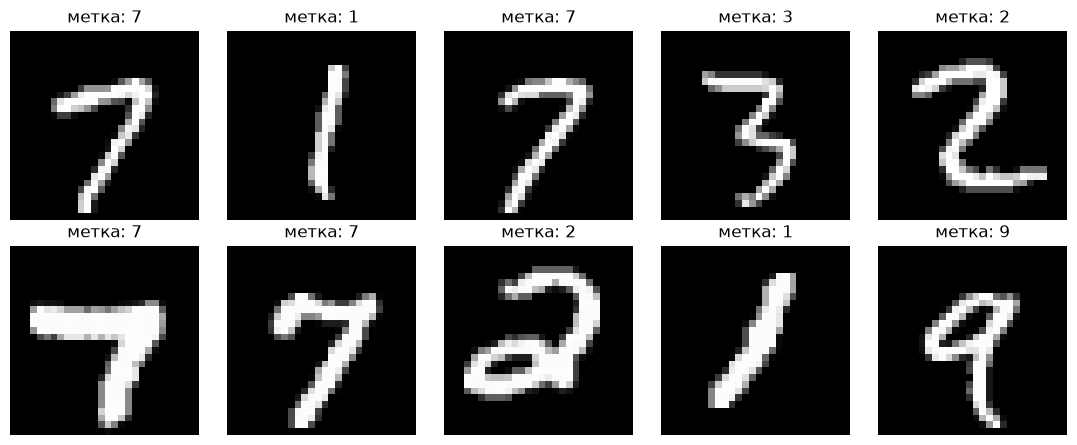

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(11, 4.5))

for ax, i in zip(axes.flatten(), range(10)):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title("метка: " + str(y[i]))
    ax.axis("off")

plt.tight_layout()
plt.show()

Картинки нормальные, метки совпадают с изображением — данные отобраны правильно.

## Часть 2. Модель и функция обучения

Модель берем из задания 10: полносвязная сеть с ReLU на скрытом слое, 784 входных нейрона и
10 выходных, softmax внутри `nn.CrossEntropyLoss`, оптимизатор Adam с lr = 0.001, обучение
обычным циклом по эпохам с перемешиванием через `torch.randperm`.

Единственное изменение — скрытый слой уменьшен с 128 до 32 нейронов. Это разрешено условием
(«если обучение все еще долгое, используйте меньше слоев и нейронов»): Leave-one-out — это 500
полных обучений сети, и с сетью из задания 10 ноутбук считался бы слишком долго. Число эпох и
размер батча одинаковые для всех четырех вариантов разбиения, иначе варианты нельзя было бы
сравнивать между собой.

In [5]:
EPOCHS = 30
BATCH = 32


def train_and_predict(X_train, y_train, X_test):
    Xtr = torch.tensor(X_train)
    ytr = torch.tensor(y_train, dtype=torch.long)
    Xte = torch.tensor(X_test)

    # каждый раз обучаем сеть с нуля, иначе фолды будут «подглядывать» друг в друга
    model = nn.Sequential(
        nn.Linear(784, 32), nn.ReLU(),
        nn.Linear(32, 10),
    )
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=0.001)

    for ep in range(EPOCHS):
        idx = torch.randperm(len(Xtr))
        for i in range(0, len(Xtr), BATCH):
            b = idx[i:i + BATCH]
            opt.zero_grad()
            loss = loss_fn(model(Xtr[b]), ytr[b])
            loss.backward()
            opt.step()

    with torch.no_grad():
        return model(Xte).argmax(dim=1).numpy()

Задача многоклассовая, поэтому Precision, Recall и F1 считаем с усреднением `macro` — по всем
10 цифрам, как в задании 10. `zero_division=0` нужен для маленьких тестовых выборок: если какой-то
цифры в тесте нет, sklearn иначе ругается.

In [6]:
def metrics(y_true, y_pred):
    return [accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred, average="macro", zero_division=0),
            recall_score(y_true, y_pred, average="macro", zero_division=0),
            f1_score(y_true, y_pred, average="macro", zero_division=0)]


names = ["Accuracy", "Precision", "Recall", "F1"]

# сюда складываем метрики по всем фолдам и общее время для каждого варианта разбиения
scores_all = {}
times = {}

Самый дорогой вариант — Leave-one-out, это 500 обучений сети. Прикинем заранее, сколько он займет:
замерим одно обучение на 499 примерах и умножим на 500.

In [7]:
train_and_predict(X[:499], y[:499], X[499:])   # первый запуск разогревает torch, его не замеряем

t0 = time.time()
train_and_predict(X[:499], y[:499], X[499:])
t_one = time.time() - t0

print("одно обучение: %.3f с" % t_one)
print("оценка времени Leave-one-out (500 обучений): %.0f с" % (t_one * 500))

одно обучение: 0.083 с
оценка времени Leave-one-out (500 обучений): 42 с


Одно обучение занимает меньше десятой доли секунды, значит Leave-one-out уложится примерно
в 40 секунд — с такой сетью и таким числом эпох работать можно.

## Часть 3. Оценка модели разными вариантами разбиения

### Шаг 1. Train-test split со стратификацией

Разбиение как в задании 10: 70% на обучение, 30% на тест, `stratify=y` — доли классов в обеих частях
одинаковые. Одно разбиение дает всего одно значение метрики, и дисперсию по нему посчитать нельзя,
поэтому повторяем случайное стратифицированное разбиение 5 раз с разными `random_state` и усредняем
по этим 5 ответам.

In [8]:
t0 = time.time()
scores = []

for rs in range(5):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=rs, stratify=y)
    y_pred = train_and_predict(X_train, y_train, X_test)
    scores.append(metrics(y_test, y_pred))

times["Train-test split"] = time.time() - t0
scores_all["Train-test split"] = np.array(scores)

print("обучений:", len(scores), " время: %.1f с" % times["Train-test split"])
pd.DataFrame({"среднее": scores_all["Train-test split"].mean(axis=0).round(4),
              "дисперсия": scores_all["Train-test split"].var(axis=0).round(5)}, index=names)

обучений: 5  время: 0.3 с


,среднее,дисперсия
Accuracy,0.8600,0.00050
Precision,0.8684,0.00036
Recall,0.8600,0.00050
F1,0.8580,0.00051


Accuracy около 0.86 — заметно ниже, чем 0.978 в задании 10, но это ожидаемо: там сеть училась на
60000 примерах, а здесь на 350. Дисперсия очень маленькая (0.0005), но она посчитана всего по
5 разбиениям и говорит только о разбросе между ними, а не о надежности оценки.

### Шаг 2. K-fold со стратификацией, k = 10

Выборка делится на 10 частей с сохранением долей классов; каждая часть по очереди становится
тестовой, остальные 9 — обучающими. Итого 10 обучений, метрики усредняем по 10 ответам.

In [9]:
t0 = time.time()
scores = []

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
for train_idx, test_idx in skf.split(X, y):
    y_pred = train_and_predict(X[train_idx], y[train_idx], X[test_idx])
    scores.append(metrics(y[test_idx], y_pred))

times["K-fold (k=10)"] = time.time() - t0
scores_all["K-fold (k=10)"] = np.array(scores)

print("обучений:", len(scores), " время: %.1f с" % times["K-fold (k=10)"])
pd.DataFrame({"среднее": scores_all["K-fold (k=10)"].mean(axis=0).round(4),
              "дисперсия": scores_all["K-fold (k=10)"].var(axis=0).round(5)}, index=names)

обучений: 10  время: 0.8 с


,среднее,дисперсия
Accuracy,0.8760,0.00158
Precision,0.8939,0.00118
Recall,0.8760,0.00158
F1,0.8738,0.00164


Средние значения почти те же, что и у train-test split, но теперь в оценке участвует каждый объект
выборки, и дисперсия честно посчитана по 10 независимым тестовым частям (по 50 объектов в каждой).

### Шаг 3. Leave-one-out

Крайний случай кросс-валидации: тестовая выборка — один объект, обучающая — остальные 499.
Всего N = 500 обучений, метрики усредняем по 500 ответам.

In [10]:
t0 = time.time()
scores = []

loo = LeaveOneOut()
for train_idx, test_idx in loo.split(X):
    y_pred = train_and_predict(X[train_idx], y[train_idx], X[test_idx])
    scores.append(metrics(y[test_idx], y_pred))

times["Leave-one-out"] = time.time() - t0
scores_all["Leave-one-out"] = np.array(scores)

print("обучений:", len(scores), " время: %.1f с" % times["Leave-one-out"])
pd.DataFrame({"среднее": scores_all["Leave-one-out"].mean(axis=0).round(4),
              "дисперсия": scores_all["Leave-one-out"].var(axis=0).round(5)}, index=names)

обучений: 500  время: 41.4 с


,среднее,дисперсия
Accuracy,0.874,0.11012
Precision,0.874,0.11012
Recall,0.874,0.11012
F1,0.874,0.11012


Все четыре метрики совпали до последнего знака, а дисперсия получилась огромной (0.110) — так и
должно быть. В каждом фолде Leave-one-out тестовый объект всего один, поэтому на отдельном фолде
любая метрика равна 0 (не угадали) или 1 (угадали), и Precision, Recall и F1 вырождаются в ту же
самую Accuracy. Дисперсия здесь — это дисперсия бернуллиевской величины p(1 - p) = 0.874 * 0.126,
она характеризует не разброс оценки качества, а то, что отдельный ответ бинарный. Осмысленно
интерпретировать в Leave-one-out можно только среднее: 0.874 — это доля верно распознанных
объектов из всех 500.

### Шаг 4. Leave-p-out, p = 20

Полный Leave-p-out перебирает **все** подмножества размера p. При N = 500 и p = 20 таких
подмножеств C(500, 20) ≈ 2.6 * 10^35 — столько обучений сети не посчитать никогда, поэтому
`sklearn.model_selection.LeavePOut(p=20)` здесь просто нельзя запустить. Посмотрим на это число.

In [11]:
from math import comb

print("число разбиений в полном leave-p-out: C(500, 20) =", comb(500, 20))
print("при 0.05 с на обучение это %.2e лет" % (comb(500, 20) * 0.05 / 60 / 60 / 24 / 365))

число разбиений в полном leave-p-out: C(500, 20) = 266719851283743829654740530950952475
при 0.05 с на обучение это 4.23e+26 лет


Поэтому вместо полного перебора берем **ограниченную случайную выборку разбиений**: 50 раз случайно
выбираем 20 объектов в тест, остальные 480 — в обучение, и усредняем метрики по этим 50 ответам.
Это осознанное упрощение схемы: мы оцениваем то же самое среднее, что и полный leave-p-out, но по
случайной подвыборке разбиений, а не по всем.

In [12]:
t0 = time.time()
scores = []

p = 20
n_splits = 50                      # сколько случайных разбиений берем вместо полного перебора

for it in range(n_splits):
    test_idx = np.random.choice(len(X), size=p, replace=False)
    train_idx = np.setdiff1d(np.arange(len(X)), test_idx)
    y_pred = train_and_predict(X[train_idx], y[train_idx], X[test_idx])
    scores.append(metrics(y[test_idx], y_pred))

times["Leave-p-out (p=20)"] = time.time() - t0
scores_all["Leave-p-out (p=20)"] = np.array(scores)

print("обучений:", len(scores), " время: %.1f с" % times["Leave-p-out (p=20)"])
pd.DataFrame({"среднее": scores_all["Leave-p-out (p=20)"].mean(axis=0).round(4),
              "дисперсия": scores_all["Leave-p-out (p=20)"].var(axis=0).round(5)}, index=names)

обучений: 50  время: 3.9 с


,среднее,дисперсия
Accuracy,0.8700,0.00790
Precision,0.8506,0.01231
Recall,0.8446,0.01265
F1,0.8281,0.01387


Accuracy та же, что у остальных вариантов, а вот macro-Precision, Recall и F1 вышли ниже: в тесте
всего 20 объектов на 10 классов, часть цифр попадает в тест по одному разу или не попадает вовсе,
и macro-усреднение по таким крошечным группам смещает метрику вниз. Дисперсия больше, чем у k-fold,
потому что тестовая часть в 2.5 раза меньше (20 объектов против 50).

## Часть 4. Сравнение вариантов разбиения

### Шаг 1. Сводная таблица

In [13]:
rows = []
for name in scores_all:
    s = scores_all[name]
    row = {}
    for j in range(4):
        row[names[j] + ", среднее"] = round(s[:, j].mean(), 4)
        row[names[j] + ", дисперсия"] = round(s[:, j].var(), 5)
    rows.append(row)

res = pd.DataFrame(rows, index=list(scores_all.keys()))
res.T

,Train-test split,K-fold (k=10),Leave-one-out,Leave-p-out (p=20)
"Accuracy, среднее",0.86000,0.87600,0.87400,0.87000
"Accuracy, дисперсия",0.00050,0.00158,0.11012,0.00790
"Precision, среднее",0.86840,0.89390,0.87400,0.85060
"Precision, дисперсия",0.00036,0.00118,0.11012,0.01231
"Recall, среднее",0.86000,0.87600,0.87400,0.84460
"Recall, дисперсия",0.00050,0.00158,0.11012,0.01265
"F1, среднее",0.85800,0.87380,0.87400,0.82810
"F1, дисперсия",0.00051,0.00164,0.11012,0.01387


И отдельно — сколько обучений сети потребовал каждый вариант и сколько это заняло времени.

In [14]:
cost = pd.DataFrame({
    "обучений сети": [len(scores_all[name]) for name in scores_all],
    "время, с": [round(times[name], 1) for name in scores_all],
}, index=list(scores_all.keys()))
cost

,обучений сети,"время, с"
Train-test split,5,0.3
K-fold (k=10),10,0.8
Leave-one-out,500,41.4
Leave-p-out (p=20),50,3.9


### Шаг 2. График метрик: средние значения и разброс

Строим по одному графику на метрику: столбик — среднее значение, вертикальная черта — разброс
(стандартное отклонение, то есть корень из дисперсии).

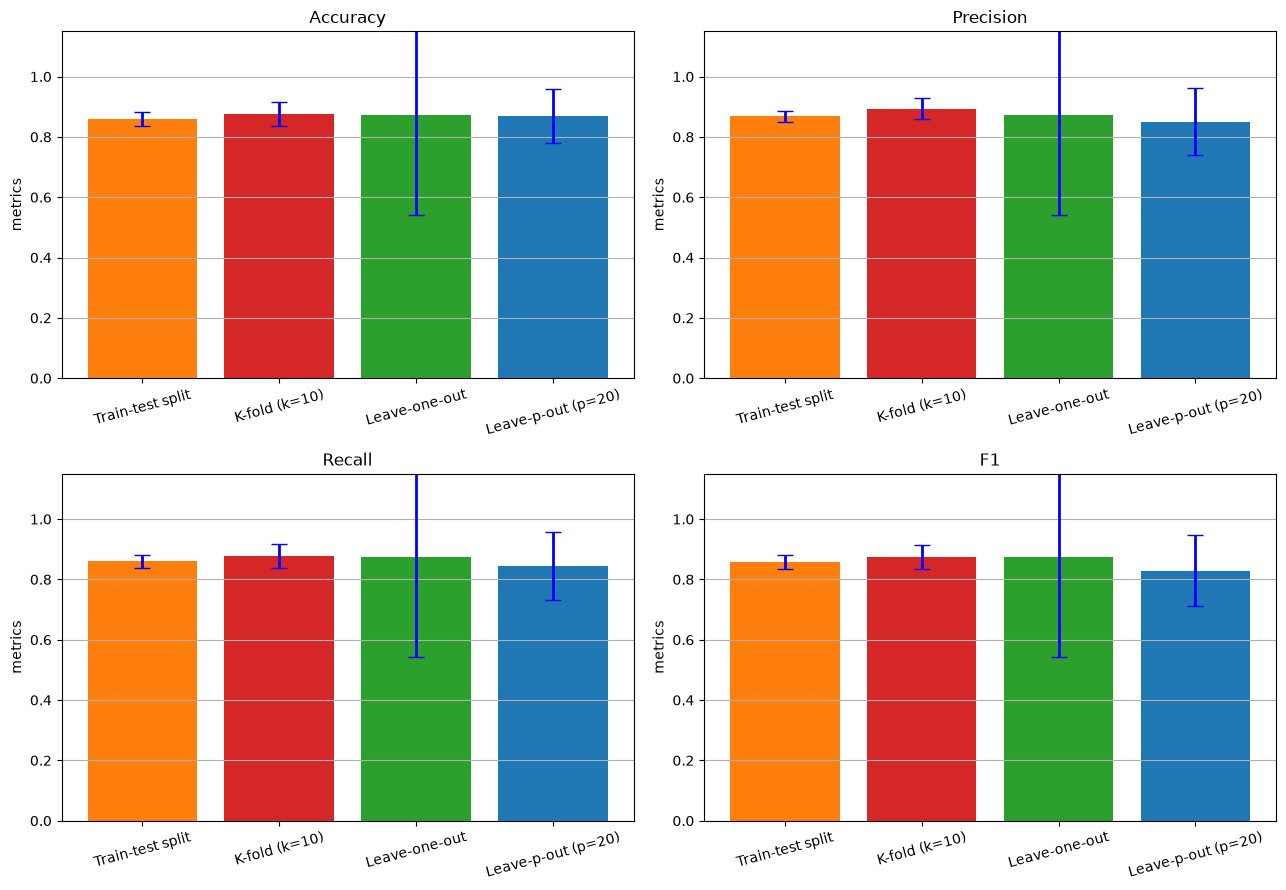

In [15]:
labels = list(scores_all.keys())
colors = ["tab:orange", "tab:red", "tab:green", "tab:blue"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for j, ax in enumerate(axes.flatten()):
    means = [scores_all[name][:, j].mean() for name in labels]
    stds = [scores_all[name][:, j].std() for name in labels]

    ax.bar(labels, means, color=colors, yerr=stds, capsize=6,
           error_kw={"ecolor": "blue", "elinewidth": 2})
    ax.set_title(names[j])
    ax.set_ylabel("metrics")
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(True, axis="y")

plt.tight_layout()
plt.show()

Средние значения всех четырех вариантов лежат близко (Accuracy 0.86-0.88), то есть само качество
модели схема разбиения почти не меняет. Меняется разброс: у Leave-one-out черта разброса огромная
просто потому, что отдельный ответ там равен 0 или 1; у leave-p-out разброс больше, чем у k-fold,
из-за маленькой тестовой части; у train-test split он формально самый маленький, но посчитан всего
по 5 повторам, так что доверия к нему меньше всего.

### Шаг 3. График временных затрат

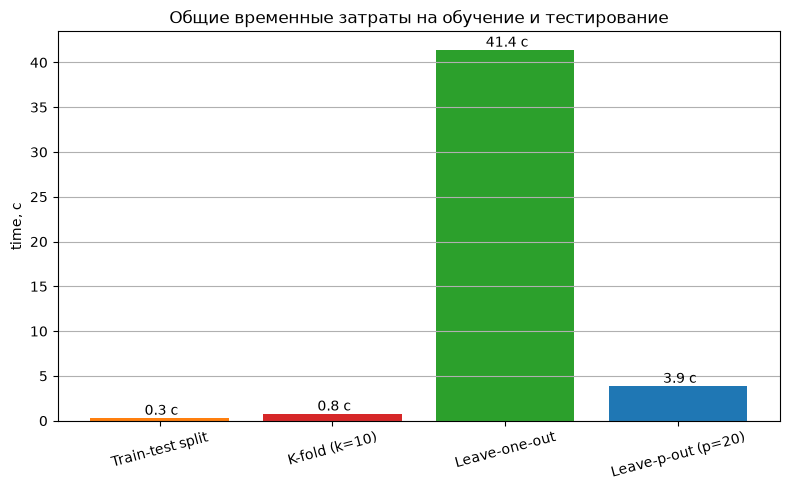

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(labels, [times[name] for name in labels], color=colors)
plt.ylabel("time, с")
plt.title("Общие временные затраты на обучение и тестирование")
plt.xticks(rotation=15)
plt.grid(True, axis="y")

for i, name in enumerate(labels):
    plt.text(i, times[name], " %.1f с" % times[name], ha="center", va="bottom")

plt.tight_layout()
plt.show()

Время прямо пропорционально числу обучений сети: 5 обучений у train-test split, 10 у k-fold,
50 у урезанного leave-p-out и 500 у Leave-one-out. Столбик Leave-one-out (41 с) настолько выше
остальных, что первые два на графике почти не видны: он дороже k-fold в 50 раз при том же
результате. А полный leave-p-out не влез бы вообще — и это на выборке всего из 500 объектов.

## Выводы

Все четыре схемы разбиения дали примерно одинаковую оценку качества модели из задания 10 на
500 примерах MNIST — Accuracy 0.86-0.88. Различаются они не средним, а надежностью оценки и ценой:

- **Train-test split** самый дешевый (5 обучений, меньше секунды), но каждое отдельное разбиение дает
  единственное число: в оценке участвует только 30% выборки, а при другом `random_state` результат
  сдвигается. Это самая шумная и наименее информативная оценка.
- **K-fold (k = 10)** — разумный компромисс: каждый объект ровно один раз побывал в тесте, дисперсия
  считается по 10 независимым тестовым частям по 50 объектов, а стоит это всего 10 обучений.
- **Leave-one-out** использует максимум данных для обучения (499 из 500) и дает самую надежную
  среднюю оценку, но стоит 500 обучений — в 50 раз дороже k-fold при том же результате. Плюс
  per-fold метрики в нем вырождаются: тестовый объект один, поэтому Precision, Recall и F1
  совпадают с Accuracy, а дисперсия перестает что-либо значить.
- **Leave-p-out (p = 20)** в полном виде невычислим: C(500, 20) ≈ 2.6 * 10^35 разбиений. Пришлось
  усреднять по 50 случайно выбранным разбиениям — оценка получается близкой к k-fold, но с большим
  разбросом, потому что тест из 20 объектов слишком мал для macro-метрик по 10 классам.

Итог: LOO и leave-p-out теоретически дают самую полную оценку, но их стоимость растет непропорционально
качеству оценки, а leave-p-out при заметном p вообще не считается. На практике для такой задачи
достаточно стратифицированного k-fold, а простой train-test split годится только для быстрой прикидки.